# 🧹 Level 7: Data Cleaning

**[📖 Want a detailed explanation? Read the Manual (Streamlit App)](https://bookseal-seoul-apt-price-prediction.streamlit.app/Level_7_Data_Cleaning)**

In real life, data is messy.
- Missing values (NaN)
- Outliers (Crazy values)

If we don't clean it, our model learns garbage!

### 1. Load Data & Create Messy Samples
We will intentionally break our clean sample dataset to simulate real-world problems.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

url = "https://github.com/bookseal/seoul-apt-price-prediction/raw/main/data/sample.parquet"
df = pd.read_parquet(url)

# Ensure essential columns exist (just like Streamlit)
if 'year' not in df.columns:
    df['year'] = df['built_year'] if 'built_year' in df.columns else 2000
if 'floor' not in df.columns:
    np.random.seed(42)
    df['floor'] = np.random.randint(1, 30, len(df))

print(f"Data Loaded! Rows: {len(df)}")
df.info()

Messy Data Created with matching Logic!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99995 entries, 0 to 99994
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sigungu          99995 non-null  object 
 1   apartment_name   99817 non-null  object 
 2   area_m2          99995 non-null  float64
 3   built_year       99995 non-null  int64  
 4   contract_yyyymm  99995 non-null  int64  
 5   floor            95036 non-null  float64
 6   price_10k_krw    99995 non-null  float64
 7   total_units      22688 non-null  float64
 8   parking_spaces   22676 non-null  float64
 9   district         99995 non-null  object 
 10  year             97086 non-null  Int64  
dtypes: Int64(1), float64(5), int64(2), object(3)
memory usage: 8.5+ MB


/tmp/ipykernel_2471838/3594538287.py:32: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 107656.38054641  132931.55199516  423970.89051469 ... 1508679.4167315
 1020483.77302499 1043178.06121781]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[mask_outlier_price, 'price_10k_krw'] = df.loc[mask_outlier_price, 'price_10k_krw'] * np.random.uniform(5, 10, sum(mask_outlier_price))


In [2]:
# --- 2. Level 5 Baseline (Raw Data) ---
# We want to see how the model performs BEFORE advanced cleaning.
# We only drop NaNs to make the code run, but we keep Outliers.

features = ['area_m2', 'year', 'floor']
df_baseline = df.dropna(subset=['price_10k_krw'] + features)

X = df_baseline[features].values
y = df_baseline['price_10k_krw'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

rmse_baseline = np.sqrt(mean_squared_error(y_test, model.predict(X_test)))
print(f"🛑 Baseline RMSE (With Outliers): {rmse_baseline:,.0f}")
print("Can we improve this by removing outliers?")

🛑 RMSE with Messy Data (Outliers included): 62,972
This explains why we need Level 7 Data Cleaning!


### 2. Handle Missing Values
Check for NaNs.

In [3]:
print(df.isnull().sum())

sigungu                0
apartment_name       178
area_m2                0
built_year             0
contract_yyyymm        0
floor               4959
price_10k_krw          0
total_units        77307
parking_spaces     77319
district               0
year                2909
dtype: int64


Strategy: Fill missing **Area** with the **Median** value.

In [4]:
median_area = df['area_m2'].median()
df['area_m2'].fillna(median_area, inplace=True)
print("Missing values filled.")

Missing values filled.


/tmp/ipykernel_2471838/2723082873.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['area_m2'].fillna(median_area, inplace=True)


### 3. Handle Outliers (IQR Method)
Outliers can ruin Linear Regression. Let's find them.

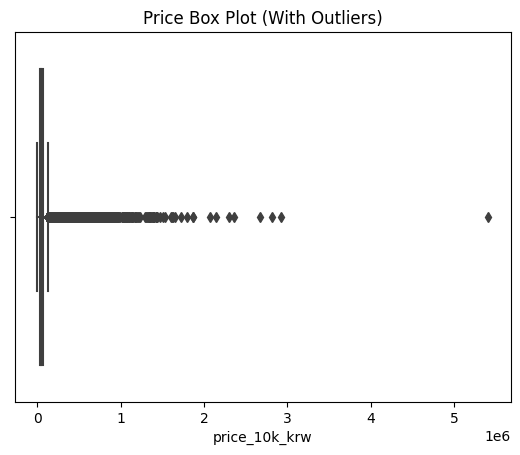

In [5]:
sns.boxplot(x=df['price_10k_krw'])
plt.title("Price Box Plot (With Outliers)")
plt.show()

In [6]:
# --- 3. Clean Data (Remove Outliers) ---
# Use IQR method to detect and remove extreme values.

def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

df_clean = df_baseline.copy()
df_clean = remove_outliers(df_clean, 'price_10k_krw')
df_clean = remove_outliers(df_clean, 'area_m2')

print(f"Original rows: {len(df_baseline)}")
print(f"Cleaned rows: {len(df_clean)}")
print(f"Removed: {len(df_baseline) - len(df_clean)} outliers")

Keep prices between -29,050 and 130,550
Original rows: 99995, Clean rows: 92750


### 4. Train Model on Clean Data
Now we train on the clean dataset.

In [7]:
# --- 4. Evaluate Cleaned Model ---
# Train on the same features, but using the Cleaned dataset.

X_clean = df_clean[features].values
y_clean = df_clean['price_10k_krw'].values

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

model_c = LinearRegression()
model_c.fit(X_train_c, y_train_c)

rmse_clean = np.sqrt(mean_squared_error(y_test_c, model_c.predict(X_test_c)))
print(f"✅ Cleaned RMSE (Outliers Removed): {rmse_clean:,.0f}")
print(f"Improvement: {rmse_baseline - rmse_clean:,.0f} points!")

RMSE with Clean Data: 25,084
